# PCA on Fraud Subset

We run PCA on the **fraud-only** subset to test whether fraud transactions live in a low-dimensional subspace.

- **Motivation:** Strong correlations in feature blocks (e.g. V1–V19, V19–V23) suggest fraud may lie in a compressed subspace.
- **Goal:** Reveal latent structure specific to fraud and support downstream modeling.

In [1]:
import pandas as pd

df = pd.read_csv("dataset/creditcard_2023.csv")  # check file
# V1-V28: Anonymized features representing various transaction attributes (e.g., time, location, etc.)
df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [3]:
fraud_only = df[df["Class"] == 1]
fraud_only.head()


,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,541,-0.478427,0.142165,-0.046838,0.683350,0.067820,-0.404898,-0.206496,0.184366,-0.762935,...,0.098977,-0.075191,-0.481489,0.678900,-0.011520,0.409021,0.075859,-0.447139,1534.53,1
623,623,-0.617111,-1.733888,1.150655,0.207829,0.903533,-0.171524,0.551679,-0.167744,0.338861,...,0.153856,0.369734,1.471004,-0.497633,0.377656,-0.328051,-0.512415,-0.013653,10554.68,1
4920,4920,-0.476617,0.088942,0.326333,0.220370,-0.026730,0.432409,0.646165,-0.240646,0.356997,...,-0.223141,-0.851929,0.153117,-0.127032,-0.334872,-1.353308,-0.192302,-0.470796,2785.98,1
6108,6108,-0.832953,-0.024254,-0.260967,0.323532,-0.117119,-0.589167,-0.390612,-0.207889,0.351702,...,0.120451,0.121804,-0.453630,-0.064071,0.331833,-1.671579,-1.060239,1.939783,15897.18,1
6329,6329,1.020308,0.425645,-0.554113,0.868349,2.367343,-0.360087,1.185828,-0.261569,-0.159521,...,-0.258401,-0.661236,-0.663639,-2.536292,2.502489,1.195597,-0.249226,0.254373,3492.59,1


In [4]:
len(fraud_only)

284315

In [5]:
# Extract feature matrix: fraud samples, V1–V28 only
feature_cols = [f"V{i}" for i in range(1, 29)]
X_fraud = fraud_only[feature_cols].values  # shape: (n_fraud, 28)
print(f"X_fraud shape: {X_fraud.shape}")

X_fraud shape: (284315, 28)


In [6]:
from sklearn.decomposition import PCA

# Fit PCA on fraud-only data (new coordinate system from fraud covariance)
pca_fraud = PCA()
pca_fraud.fit(X_fraud)
evr = pca_fraud.explained_variance_ratio_
evr_cumsum = evr.cumsum()

In [ ]:
# Explained variance ratio (individual and cumulative)
# The explained variance ratio in PCA measures the proportion of a dataset's total variance (information) 
# captured by each principal component. 
# It helps identify how many components are needed to retain most of the data's structure, 
# with the first component capturing the highest variance. 
# It is calculated as the ratio of a component's eigenvalue to the sum of all eigenvalues
import numpy as np

evr_df = pd.DataFrame({
    "PC": range(1, len(evr) + 1),
    "Explained variance ratio": evr,
    "Cumulative": evr_cumsum,
})
display(evr_df)

,PC,Explained variance ratio,Cumulative
0,1,0.321879,0.321879
1,2,0.166647,0.488526
2,3,0.113609,0.602135
3,4,0.083173,0.685307
4,5,0.055522,0.740829
5,6,0.044929,0.785758
6,7,0.035490,0.821247
7,8,0.029346,0.850594
8,9,0.027397,0.877991
9,10,0.020457,0.898447


In [8]:
# Key diagnostic: how many components to reach 80% and 95%?
k_80 = np.searchsorted(evr_cumsum, 0.80) + 1   # 1-based index
k_95 = np.searchsorted(evr_cumsum, 0.95) + 1
print(f"Components needed for 80% variance: {k_80}")
print(f"Components needed for 95% variance: {k_95}")
print(f"\nCumulative variance at k=5: {evr_cumsum[4]:.4f}")
print(f"Cumulative variance at k=10: {evr_cumsum[9]:.4f}")
print(f"Cumulative variance at k=15: {evr_cumsum[14]:.4f}")

Components needed for 80% variance: 7
Components needed for 95% variance: 14

Cumulative variance at k=5: 0.7408
Cumulative variance at k=10: 0.8984
Cumulative variance at k=15: 0.9600


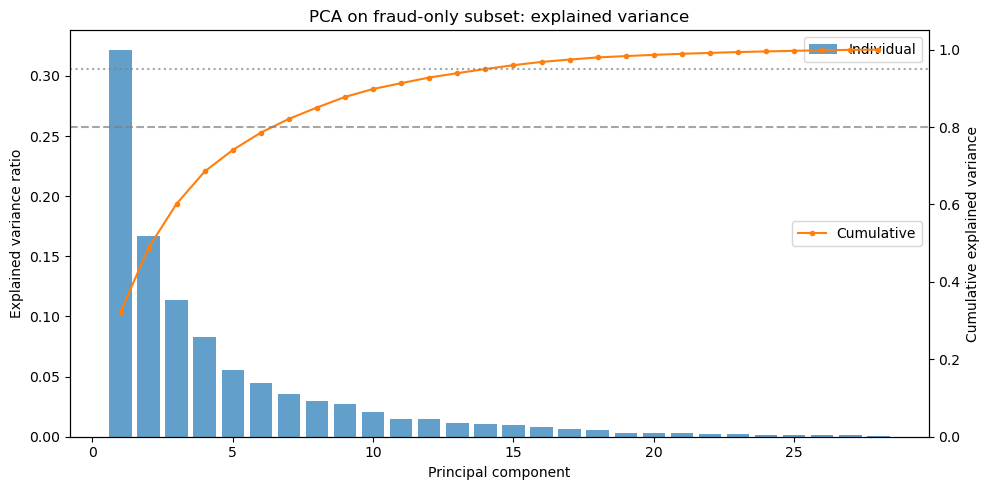

In [9]:
# Visualize explained variance (bar + cumulative line)
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(evr_df["PC"], evr_df["Explained variance ratio"], alpha=0.7, label="Individual")
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Explained variance ratio")
ax2 = ax1.twinx()
ax2.plot(evr_df["PC"], evr_df["Cumulative"], color="C1", marker=".", label="Cumulative")
ax2.axhline(0.80, color="gray", linestyle="--", alpha=0.7)
ax2.axhline(0.95, color="gray", linestyle=":", alpha=0.7)
ax2.set_ylabel("Cumulative explained variance")
ax2.set_ylim(0, 1.05)
ax2.legend(loc="center right")
ax1.legend(loc="upper right")
plt.title("PCA on fraud-only subset: explained variance")
plt.tight_layout()
plt.show()

---

## Component loadings (`components_`)

**What are they?**  
PCA finds new axes ("principal components") along which the data vary most. Each PC is a **linear combination of the original variables**:

- **PC1** = w₁·V1 + w₂·V2 + … + w₂₈·V28  
- **PC2** = …  
- etc.

The coefficients (w₁, w₂, …) are the **loadings** and are stored in `pca_fraud.components_`:  
- `components_[0]` = loadings for PC1 (one weight per V1–V28)  
- `components_[1]` = loadings for PC2  
- …

**Why look at them?**  
- **Explained variance ratio** tells us *how much* variance is compressed (how many components explain 80–95%).  
- It does **not** tell us *which* original variables are grouped together in each component.  
- Loadings answer: **"what factors are together?"** — which V’s move together in fraud.  
- So we can check whether blocks like V1–V19 or V19–V23 form the low-dimensional structure we suspected from the covariance heatmap.

explained_variance_ratio는
👉 "얼마나 데이터 분포 형태에 기여하는가"

components_는
👉 "어떤 변수들이 묶여서 기여하는가"

In [15]:
# Loadings: each row = one PC, each column = weight for V1..V28
loadings = pd.DataFrame(
    pca_fraud.components_,
    columns=feature_cols,
    index=[f"PC{i}" for i in range(1, 29)],
)

# Top variables contributing to PC1 (by absolute loading)
print("PC1 — top 10 variables by |loading|:")
display(loadings.loc["PC1"].abs().sort_values(ascending=False).head(10))

PC1 — top 10 variables by |loading|:


V17    0.338292
V18    0.322861
V5     0.311573
V16    0.287736
V7     0.284037
V19    0.239736
V1     0.236132
V10    0.234112
V2     0.227058
V9     0.221509
Name: PC1, dtype: float64

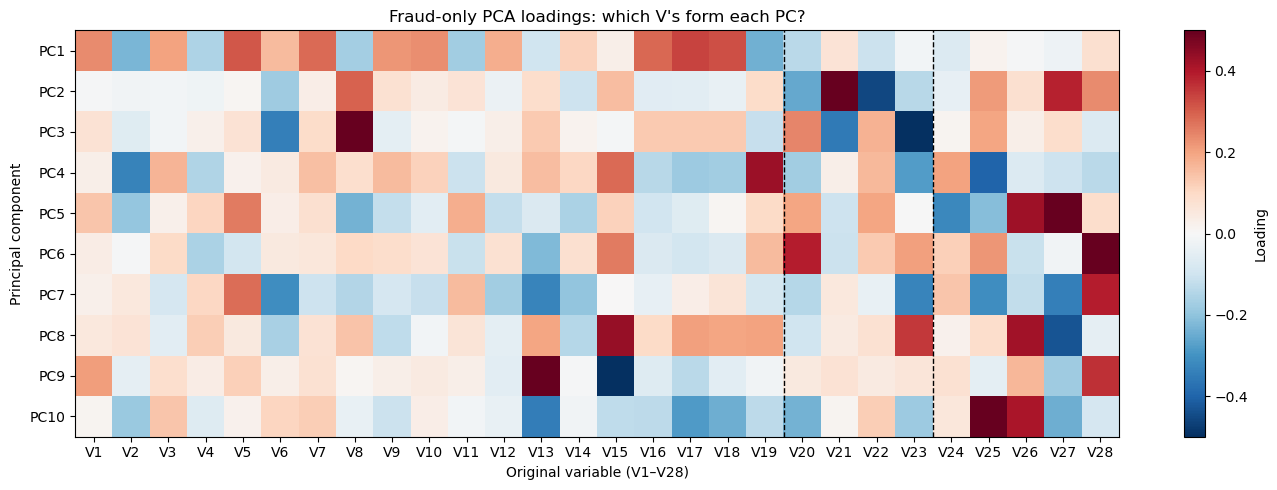

In [16]:
# Heatmap: which V's load on which PCs (first k PCs that explain ~80–95%)
n_pcs_show = 10  # top 10 PCs
loadings_show = loadings.iloc[:n_pcs_show]

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(loadings_show.values, aspect="auto", cmap="RdBu_r", vmin=-0.5, vmax=0.5)
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols)
ax.set_yticks(range(n_pcs_show))
ax.set_yticklabels(loadings_show.index)
ax.set_xlabel("Original variable (V1–V28)")
ax.set_ylabel("Principal component")
plt.colorbar(im, ax=ax, label="Loading")
# Highlight blocks V1–V19 and V19–V23 (vertical bands)
ax.axvline(18.5, color="black", linewidth=1, linestyle="--")
ax.axvline(22.5, color="black", linewidth=1, linestyle="--")
ax.set_title("Fraud-only PCA loadings: which V's form each PC?")
plt.tight_layout()
plt.show()

In [18]:
# Per-PC: which variable block contributes most? (mean |loading| over V1–V19 vs V19–V23 vs rest)
blocks = {
    "V1-V19": feature_cols[:19],
    "V19-V23": feature_cols[18:23],   # V19..V23
    "V24-V28": feature_cols[23:],
}
block_contrib = pd.DataFrame(
    index=loadings.index,
    columns=list(blocks.keys()),
    dtype=float,
)
for pc in loadings.index:
    for name, cols in blocks.items():
        block_contrib.loc[pc, name] = loadings.loc[pc, cols].abs().mean()
print("Mean |loading| per block for each PC (which block drives each component):")
display(block_contrib.round(4))

Mean |loading| per block for each PC (which block drives each component):


,V1-V19,V19-V23,V24-V28
PC1,0.2098,0.1127,0.0395
PC2,0.0723,0.2902,0.1907
PC3,0.1027,0.2766,0.0783
PC4,0.1517,0.2147,0.1816
PC5,0.1134,0.1193,0.3085
PC6,0.0997,0.1996,0.2260
PC7,0.1259,0.1299,0.2615
PC8,0.1294,0.1548,0.2013
PC9,0.1163,0.0494,0.1669
PC10,0.1137,0.1377,0.2578


### Interpretation (key diagnostic)

- **Do the top k principal components explain 80–95% of the total variance?**
  - If **k is small** → fraud has strong low-dimensional structure; linear classifiers (or a small set of PCA-derived features) may capture the main directions.
  - If **k is large** → fraud is broadly distributed without strong dimensional compression; QDA or nonlinear models may be more appropriate if fraud covariance differs from normal.

**Summary of interpretation**

Within fraud there are at least two main factor clusters:
- PC1 is dominated by the V1–V19 block
- PC2 and PC3 are centered on the V19–V23 block

**What this implies overall**

Fraud PCA has this structure:
- PC1 → Block A (V1–V19)
- PC2–3 → Block B (V19–V23)
- PC5–12 (partially) → Block C (V24–V28)

**From an LDA vs QDA perspective**
- There are mean differences
- Covariance structure also differs
- Moreover, fraud's internal covariance decomposes into block-wise factors
- This supports the QDA assumption (different covariance per class).

**At the same time, an important point**

The fact that each block dominates different PCs implies:
- Fraud covariance is close to a block-diagonal-like structure.
  - That is: the covariance is likely "a combination of a few independent subspaces" rather than fully complex/nonlinear.
  - So the complexity may not strictly require QDA.

**In a nutshell**

Fraud structure:
- Not random noise
- Specific latent factor groups exist
- Block-level dependency is present
- But there is no extreme low-dimensional collapse
- So it is structured, but not a full manifold collapse.
→ Fraud has a "structural covariance pattern centered on specific blocks."

**Model candidates**
- Logistic Regression
- LDA
- QDA

**Characteristics**

| Model     | Uses mean difference | Reflects covariance difference | Decision boundary | Assumption strength |
| --------- | -------------------- | -------------------------- | ------------------ | ------------------- |
| Logistic  | ✔                    | ✖                          | Linear             | Weak                |
| LDA       | ✔                    | ✖                          | Linear             | Medium              |
| QDA       | ✔                    | ✔                          | Quadratic          | Strong              |
